In [1]:
import sys
sys.path.append('..')

import numpy as np

d = np.load("Kxx_Lyy.npz")

In [2]:
Kxx = d["Kxx"]
Lyy = d["Lyy"]

In [3]:
Kxx.max()

1.0

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

(array([2.000e+00, 3.000e+00, 9.000e+00, 2.800e+01, 5.900e+01, 1.870e+02,
        4.100e+02, 1.250e+03, 3.342e+03, 2.710e+03]),
 array([0.47634065, 0.51715511, 0.55796963, 0.59878409, 0.63959861,
        0.68041307, 0.72122753, 0.76204205, 0.8028565 , 0.84367102,
        0.88448548]),
 <BarContainer object of 10 artists>)

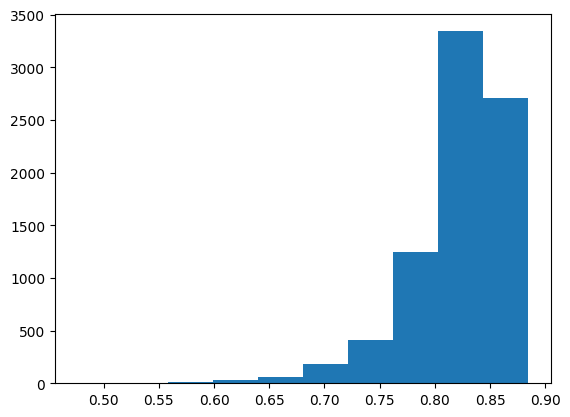

In [5]:
Kxx_means = Kxx.mean(axis=-1)
plt.hist(Kxx_means)

In [6]:
import metrics
import torch

Kxx = torch.tensor(Kxx)
Lyy = torch.tensor(Lyy)

hsic_8000 = metrics.hsic.hsic_fast(Kxx, Lyy)

In [7]:
hsic_1000 = metrics.hsic.hsic_fast(Kxx[:1000,:1000], Lyy[:1000,:1000])

In [8]:
hsic_8000, hsic_1000

((tensor(1.3755e-06), tensor(6.9629e-13)),
 (tensor(7.3972e-06), tensor(5.6322e-11)))

In [9]:
res = []
for i in range(1000):
    idx = np.random.choice(8000,1000,replace=False)
    h = metrics.hsic.hsic_fast(Kxx[np.ix_(idx, idx)], Lyy[np.ix_(idx, idx)])[0]
    res.append(h)

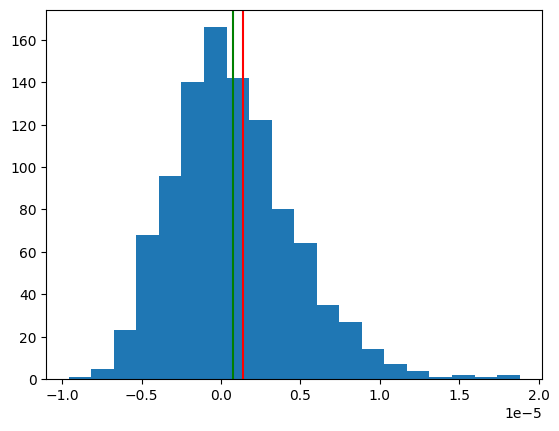

In [10]:
plt.hist(res, bins=20)
plt.axvline(hsic_8000[0], color='r')
plt.axvline(np.mean(res), color='g')